## Comparision Between Yolov8 and Yolov11

In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

## Yolov8x

In [2]:
with open('../models/tracker_stubs/ball_detection.pkl', 'rb') as f:
    yolov8 = pickle.load(f)

## Yolov11

In [3]:
with open('../models/tracker_stubs/ball_detection_y11.pkl', 'rb') as f:
    yolov11 = pickle.load(f)

## To Dataframe

In [4]:
yolov8 = [x.get(1,[]) for x in yolov8]
yolov11 = [x.get(1,[]) for x in yolov11]

df_yolov8 = pd.DataFrame(yolov8, columns = ['x1','y1','x2','y2'])
df_yolov11 = pd.DataFrame(yolov11, columns = ['x1','y1','x2','y2'])

In [5]:
df_yolov8.isna().sum()

x1    70
y1    70
x2    70
y2    70
dtype: int64

In [6]:
df_yolov11.isna().sum()

x1    82
y1    82
x2    82
y2    82
dtype: int64

In [7]:
df_yolov8.head()

,x1,y1,x2,y2
0,899.565369,558.650024,927.327271,607.980835
1,886.052673,590.864380,919.867859,657.083374
2,873.219177,626.567139,897.067017,670.044067
3,861.947083,638.314453,881.001404,676.515381
4,NaN,NaN,NaN,NaN


In [8]:
df_yolov11.head()

,x1,y1,x2,y2
0,899.291931,559.739868,927.758606,612.129272
1,891.005554,604.094543,915.442810,648.701111
2,872.942871,629.796448,898.080322,671.482971
3,860.572266,641.164917,881.108643,678.673706
4,849.312744,646.571106,873.835693,681.024963


In [9]:
def model_stats(df, name):
    stats = pd.Series()
    stats["total_frames"] = df.shape[0]
    stats["detected_frames"] = df.dropna().shape[0]
    stats["detection_rate (%)"] = 100 * stats["detected_frames"] / stats["total_frames"]

    #std of consecutive frame differences
    diffs = df[['x1', 'y1', 'x2', 'y2']].diff().dropna()
    stats["smoothness"] = diffs.std().mean()

    #avg bbox area
    df['area'] = (df['x2'] - df['x1']) * (df['y2'] - df['y1'])
    stats["avg_area"] = df['area'].mean()

    stats_df = pd.DataFrame(stats).T
    stats_df['model_name'] = name
    stats_df.set_index('model_name', inplace=True)

    return stats_df

In [10]:
stats_yolov8 = model_stats(df_yolov8, "YOLOv8")
stats_yolov11 = model_stats(df_yolov11, "YOLOv11")

comp = pd.concat([stats_yolov8, stats_yolov11], axis = 0)
comp

,total_frames,detected_frames,detection_rate (%),smoothness,avg_area
model_name,,,,,
YOLOv8,214.0,144.0,67.289720,14.581801,941.176587
YOLOv11,214.0,132.0,61.682243,14.418000,727.268121


## Plot Data

In [11]:
def show_Ball_Trajectory(dfv8, dfv11, method = "Before Interpolation"):
    dfv8["cx"] = (dfv8["x1"] + dfv8["x2"]) / 2
    dfv8["cy"] = (dfv8["y1"] + dfv8["y2"]) / 2

    dfv11["cx"] = (dfv11["x1"] + dfv11["x2"]) / 2
    dfv11["cy"] = (dfv11["y1"] + dfv11["y2"]) / 2

    plt.figure(figsize = (12,6))
    plt.plot(dfv8.index, dfv8["cy"], label = "YOLOv8", alpha = 0.7)
    plt.plot(dfv11.index, dfv11["cy"], label = "YOLOv11", alpha = 0.7)
    plt.xlabel("Frame")
    plt.ylabel("Ball Center Y")
    plt.title(f"Vertical Ball Trajectory {method}")
    plt.legend()
    plt.show()

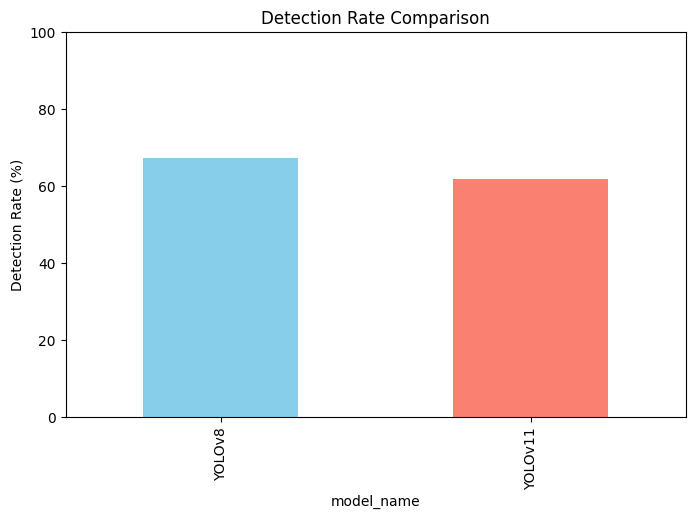

In [12]:
plt.figure(figsize = (8,5))
comp['detection_rate (%)'].plot(kind="bar", color=["skyblue", "salmon"])
plt.ylabel("Detection Rate (%)")
plt.title("Detection Rate Comparison")
plt.ylim(0, 100)
plt.show()

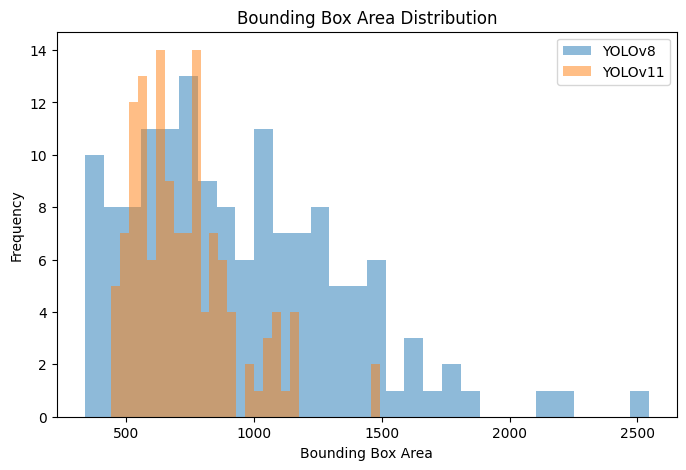

In [13]:
plt.figure(figsize = (8,5))
plt.hist(df_yolov8["area"].dropna(), bins = 30, alpha = 0.5, label = "YOLOv8")
plt.hist(df_yolov11["area"].dropna(), bins = 30, alpha = 0.5, label = "YOLOv11")
plt.xlabel("Bounding Box Area")
plt.ylabel("Frequency")
plt.title("Bounding Box Area Distribution")
plt.legend()
plt.show()

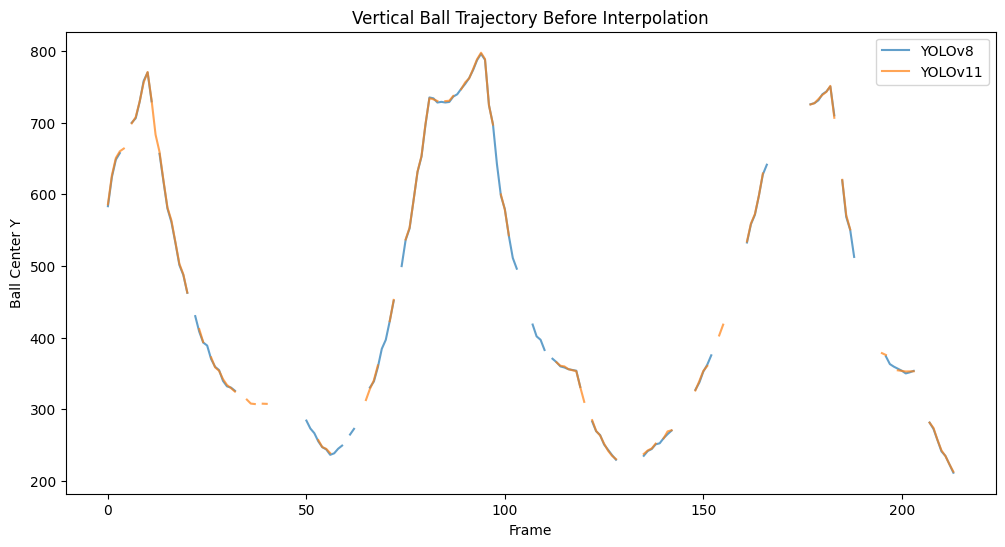

In [14]:
show_Ball_Trajectory(df_yolov8, df_yolov11)

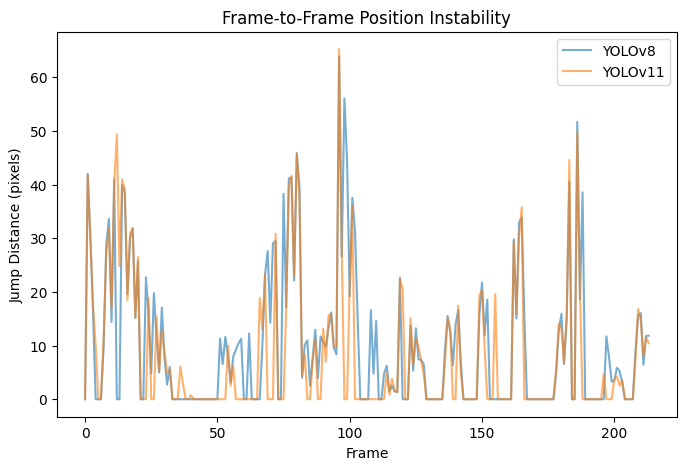

In [15]:
jump_v8 = df_yolov8[["cx","cy"]].diff().pow(2).sum(axis = 1).pow(0.5)
jump_v11 = df_yolov11[["cx","cy"]].diff().pow(2).sum(axis = 1).pow(0.5)

plt.figure(figsize = (8,5))
plt.plot(jump_v8.index, jump_v8, label = "YOLOv8", alpha = 0.6)
plt.plot(jump_v11.index, jump_v11, label = "YOLOv11", alpha = 0.6)
plt.xlabel("Frame")
plt.ylabel("Jump Distance (pixels)")
plt.title("Frame-to-Frame Position Instability")
plt.legend()
plt.show()

## Interpolation

In [16]:
df_yolov8_inter = df_yolov8.interpolate(method= 'linear') #change for cubicspline or spline and add order = 3
df_yolov11_inter = df_yolov11.interpolate(method= 'linear')

In [17]:
stats_yolov8_inter = model_stats(df_yolov8_inter, "YOLOv8")
stats_yolov11_inter = model_stats(df_yolov11_inter, "YOLOv11")

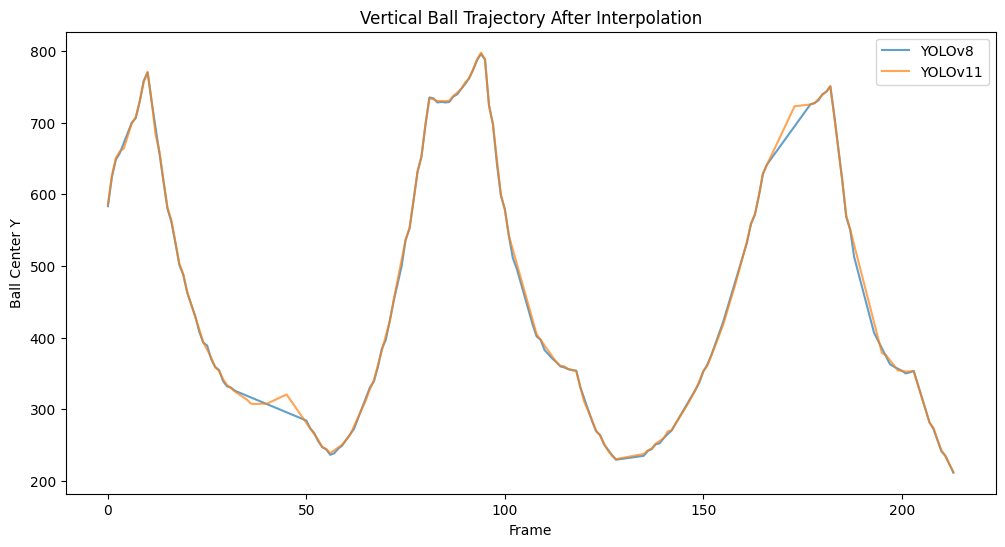

In [18]:
show_Ball_Trajectory(df_yolov8_inter, df_yolov11_inter, method = "After Interpolation")